# Magic Wand Training — TensorFlow 2.21 / Keras 3 compatible version

This notebook is a modernization of the original magic-wand training notebook. It avoids OS-specific shell commands, uses `tf.keras` consistently, exports a Keras `.keras` model plus a TensorFlow SavedModel, converts to TFLite, and generates the C array without Linux-only tools such as `apt-get`, `xxd`, or `sed`.


In [1]:
# TensorFlow 2.21 / Keras 3 compatible configuration
from pathlib import Path

DATA_DIR = Path("magic_wand_digit_data")
ARCHIVE = DATA_DIR / "magic_wand_digit_data.zip"
CHECKPOINT_DIR = Path("checkpoints")
SAVED_MODEL_DIR = Path("saved_model")
KERAS_MODEL_FILENAME = "magic_wand_model.keras"
FLOAT_TFL_MODEL_FILENAME = "float_model.tflite"
QUANTIZED_TFL_MODEL_FILENAME = "quantized_model.tflite"
TFL_CC_MODEL_FILENAME = "magic_wand_model_data.cc"

IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
BATCH_SIZE = 32
SEED = 1337


In [2]:
# Download and extract the data using only Python standard-library tools.
# This works on Windows, macOS, Linux, VSCode notebooks, and JupyterLab.

import glob
import shutil
import urllib.request
import zipfile

DATASET_URL = (
    "https://github.com/petewarden/magic_wand_digit_data/archive/"
    "8170591863f9addca27b1a963263f7c7bed33f41.zip"
)
ARCHIVE = Path("magic_wand_digit_data.zip")

def download(url: str, destination: Path) -> None:
    if destination.exists():
        print(f"Archive already exists: {destination}")
        return
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, destination)
    print(f"Downloaded: {destination.resolve()}")

def prepare_dataset() -> None:
    if DATA_DIR.exists() and any(DATA_DIR.glob("*.json")):
        print(f"Dataset already exists: {DATA_DIR.resolve()}")
        return
    else:
        DATA_DIR.mkdir(parents=True, exist_ok=True)

    download(DATASET_URL, ARCHIVE)

    # Remove stale extracted folders from previous attempts.
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)

    for candidate in Path(".").glob("magic_wand_digit_data-*"):
        if candidate.is_dir():
            shutil.rmtree(candidate)

    print("Extracting dataset...")
    with zipfile.ZipFile(ARCHIVE, "r") as zf:
        zf.extractall(".")

    extracted_dirs = sorted([p for p in Path(".").glob("magic_wand_digit_data-*") if p.is_dir()])
    if not extracted_dirs:
        raise RuntimeError("Could not find the extracted magic_wand_digit_data-* folder.")

    extracted_dirs[0].rename(DATA_DIR)
    ARCHIVE.unlink(missing_ok=True)

    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Dataset ready: {DATA_DIR.resolve()}")

prepare_dataset()
print("Example files:", [p.name for p in sorted(DATA_DIR.glob("*.json"))[:5]])


Downloaded: E:\workspace\tinyml\python\notebooks\magic_wand\magic_wand_digit_data.zip
Extracting dataset...
Dataset ready: E:\workspace\tinyml\python\notebooks\magic_wand\magic_wand_digit_data
Example files: ['petewarden_0.json', 'petewarden_1.json', 'petewarden_2.json', 'petewarden_3.json', 'petewarden_4.json']


In [3]:
import json

strokes = []
for filename in sorted(DATA_DIR.glob("*.json")):
    file_data = json.loads(filename.read_text(encoding="utf-8"))
    for stroke in file_data["strokes"]:
        stroke["filename"] = str(filename)
        strokes.append(stroke)

print(f"Loaded {len(strokes)} strokes.")
print("Example labels:", sorted({stroke["label"] for stroke in strokes})[:12])


Loaded 1000 strokes.
Example labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:
import matplotlib.pyplot as plt

def plot_stroke(stroke):
    x_array = []
    y_array = []
    for coords in stroke["strokePoints"]:
        x_array.append(coords["x"])
        y_array.append(coords["y"])

    fig = plt.figure(figsize=(12.8, 4.8))
    fig.suptitle(stroke["label"])

    ax = fig.add_subplot(131)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.4, 0.4)
    ax.plot(x_array, y_array)

    plt.show()


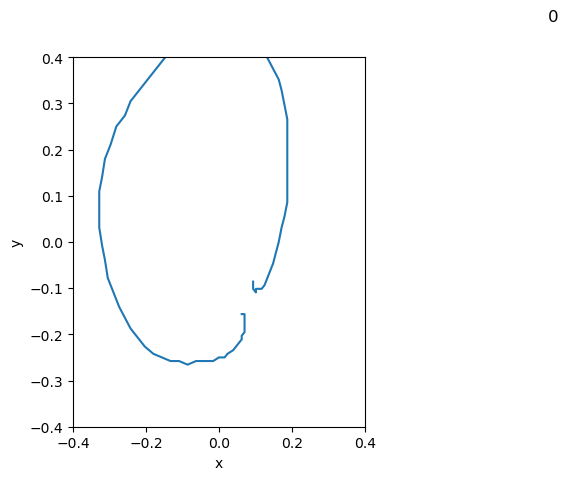

In [5]:
plot_stroke(strokes[11])

In [6]:
import math
import numpy as np
import PIL

FIXED_POINT = 256

def mul_fp(a, b):
  return (a * b) / FIXED_POINT

def div_fp(a, b):
  if b == 0:
    b = 1
  return (a * FIXED_POINT) / b

def float_to_fp(a):
  return math.floor(a * FIXED_POINT)

def norm_to_coord_fp(a, range_fp, half_size_fp):
  a_fp = float_to_fp(a)
  norm_fp = div_fp(a_fp, range_fp)
  return mul_fp(norm_fp, half_size_fp) + half_size_fp

def round_fp_to_int(a):
  return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)

def gate(a, min, max):
  if a < min:
    return min
  elif a > max:
    return max
  else:
    return a

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
  num_channels = 3
  buffer_byte_count = height * width * num_channels
  buffer = bytearray(buffer_byte_count)

  width_fp = width * FIXED_POINT
  height_fp = height * FIXED_POINT
  half_width_fp = width_fp / 2
  half_height_fp = height_fp / 2
  x_range_fp = float_to_fp(x_range)
  y_range_fp = float_to_fp(y_range)

  t_inc_fp = FIXED_POINT / len(stroke_points)

  one_half_fp = (FIXED_POINT / 2)

  for point_index in range(len(stroke_points) - 1):
    start_point = stroke_points[point_index]
    end_point = stroke_points[point_index + 1]
    start_x_fp = norm_to_coord_fp(start_point["x"], x_range_fp, half_width_fp)
    start_y_fp = norm_to_coord_fp(-start_point["y"], y_range_fp, half_height_fp)
    end_x_fp = norm_to_coord_fp(end_point["x"], x_range_fp, half_width_fp)
    end_y_fp = norm_to_coord_fp(-end_point["y"], y_range_fp, half_height_fp)
    delta_x_fp = end_x_fp - start_x_fp
    delta_y_fp = end_y_fp - start_y_fp

    t_fp = point_index * t_inc_fp
    if t_fp < one_half_fp:
      local_t_fp = div_fp(t_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = round_fp_to_int(one_minus_t_fp * 255)
      green = round_fp_to_int(local_t_fp * 255)
      blue = 0
    else:
      local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = 0
      green = round_fp_to_int(one_minus_t_fp * 255)
      blue = round_fp_to_int(local_t_fp * 255)
    red = gate(red, 0, 255)
    green = gate(green, 0, 255)
    blue = gate(blue, 0, 255)

    if abs(delta_x_fp) > abs(delta_y_fp):
      line_length = abs(round_fp_to_int(delta_x_fp))
      if delta_x_fp > 0:
        x_inc_fp = 1 * FIXED_POINT
        y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
      else:
        x_inc_fp = -1 * FIXED_POINT
        y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
    else:
      line_length = abs(round_fp_to_int(delta_y_fp))
      if delta_y_fp > 0:
        y_inc_fp = 1 * FIXED_POINT
        x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
      else:
        y_inc_fp = -1 * FIXED_POINT
        x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)
    for i in range(line_length + 1):
      x_fp = start_x_fp + (i * x_inc_fp)
      y_fp = start_y_fp + (i * y_inc_fp)
      x = round_fp_to_int(x_fp)
      y = round_fp_to_int(y_fp)
      if (x < 0) or (x >= width) or (y < 0) or (y >= height):
        continue
      buffer_index = (y * width * num_channels) + (x * num_channels)
      buffer[buffer_index + 0] = red
      buffer[buffer_index + 1] = green
      buffer[buffer_index + 2] = blue

  np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

  return np_buffer

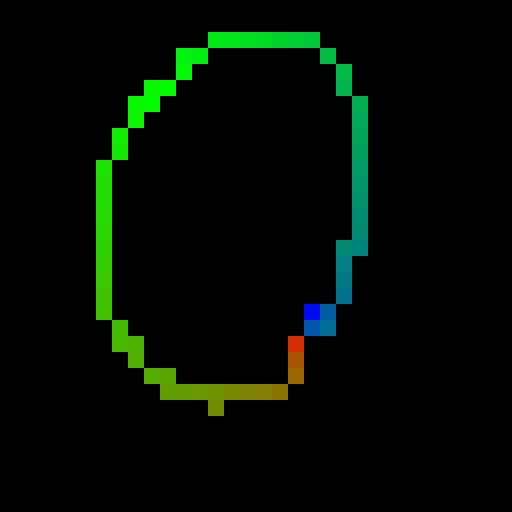

In [7]:
raster = rasterize_stroke(strokes[11]["strokePoints"], 0.5, 0.5, IMAGE_WIDTH, IMAGE_HEIGHT)
nearest = getattr(PIL.Image, "Resampling", PIL.Image).NEAREST
PIL.Image.fromarray(raster).resize((512, 512), nearest)


In [8]:
from pathlib import Path
import shutil

X_RANGE = 0.6
Y_RANGE = 0.6

def ensure_empty_dir(dirname):
    dirpath = Path(dirname)
    if dirpath.exists() and dirpath.is_dir():
        shutil.rmtree(dirpath)
    dirpath.mkdir(parents=True, exist_ok=True)

def augment_points(points, move_range, scale_range, rotate_range):
    move_x = np.random.uniform(low=-move_range, high=move_range)
    move_y = np.random.uniform(low=-move_range, high=move_range)
    scale = np.random.uniform(low=1.0 - scale_range, high=1.0 + scale_range)
    rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

    x_axis_x = math.cos(rotate) * scale
    x_axis_y = math.sin(rotate) * scale

    y_axis_x = -math.sin(rotate) * scale
    y_axis_y = math.cos(rotate) * scale

    new_points = []
    for point in points:
        old_x = point["x"]
        old_y = point["y"]
        new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
        new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
        new_points.append({"x": new_x, "y": new_y})

    return new_points

def save_strokes_as_images(strokes, root_folder, width, height, augment_count):
    root_folder = Path(root_folder)
    ensure_empty_dir(root_folder)

    labels = sorted({stroke["label"].lower() for stroke in strokes})
    for label in labels:
        ensure_empty_dir(root_folder / label)

    label_counts = {}
    for stroke in strokes:
        points = stroke["strokePoints"]
        label = stroke["label"].lower()
        if label == "":
            raise ValueError(f"Missing label for {stroke['filename']}:{stroke.get('index', 'unknown')}")

        label_count = label_counts.get(label, 0)
        label_counts[label] = label_count + 1

        raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
        image = PIL.Image.fromarray(raster)
        image.save(root_folder / label / f"{label_count}.png")

        for i in range(augment_count):
            augmented_points = augment_points(points, 0.1, 0.1, 0.3)
            raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
            image = PIL.Image.fromarray(raster)
            image.save(root_folder / label / f"{label_count}_a{i}.png")


In [9]:
np.random.seed(SEED)

shuffled_strokes = list(strokes)
np.random.shuffle(shuffled_strokes)

test_percentage = 10
validation_percentage = 10

test_count = math.floor((len(shuffled_strokes) * test_percentage) / 100)
validation_count = math.floor((len(shuffled_strokes) * validation_percentage) / 100)

test_strokes = shuffled_strokes[:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

save_strokes_as_images(test_strokes, "test", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=10)
save_strokes_as_images(validation_strokes, "validation", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=0)
save_strokes_as_images(train_strokes, "train", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=10)

print("Training images:", len(list(Path("train").glob("*/*.png"))))
print("Validation images:", len(list(Path("validation").glob("*/*.png"))))
print("Test images:", len(list(Path("test").glob("*/*.png"))))


Training images: 8800
Validation images: 100
Test images: 1100


In [10]:
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(SEED)

train_ds = keras.utils.image_dataset_from_directory(
    directory="train",
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    shuffle=True,
    seed=SEED,
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="validation",
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(AUTOTUNE)


Found 8800 files belonging to 10 classes.
Found 100 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


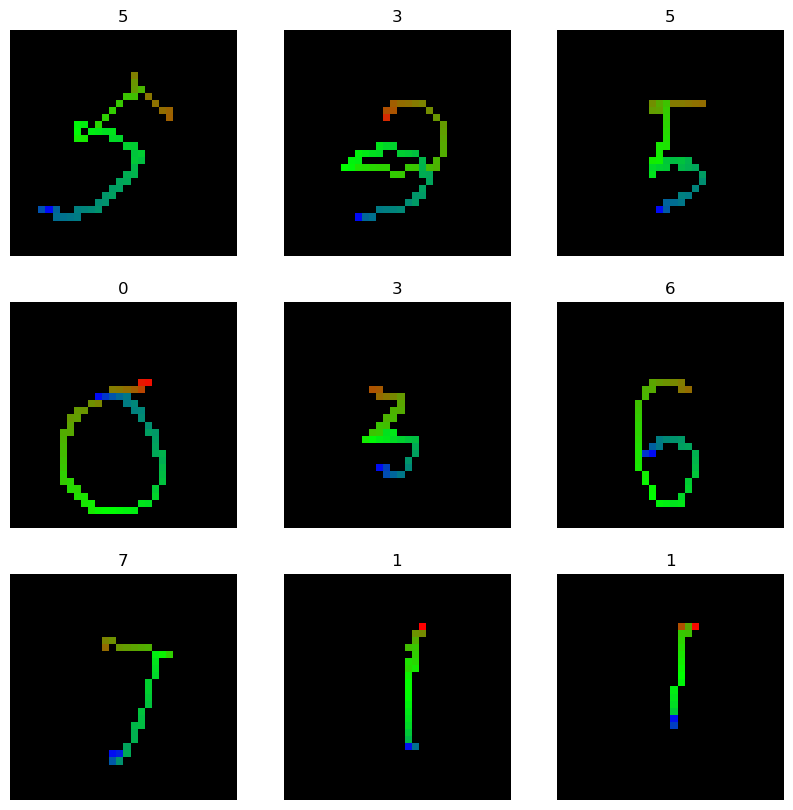

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = int(np.argmax(labels[i].numpy()))
        plt.title(class_names[label_index])
        plt.axis("off")


In [12]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = keras.layers.Rescaling(1.0 / 255)(inputs)

    x = keras.layers.Conv2D(16, 3, strides=2, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(0.5)(x)

    x = keras.layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(0.5)(x)

    x = keras.layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(0.5)(x)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.5)(x)

    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


In [13]:
model = make_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_CLASSES)
model.summary()

# Optional: this requires graphviz/pydot. The model itself does not require them.
try:
    keras.utils.plot_model(model, show_shapes=True)
except Exception as exc:
    print(f"Skipping plot_model because graphviz/pydot is not available: {exc}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,682 (96.41 KB)

 Trainable params: 24,458 (95.54 KB)

 Non-trainable params: 224 (896.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [14]:
epochs = 30

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / "magic_wand_epoch_{epoch:02d}.keras"),
        save_best_only=False,
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_ds,
)


Epoch 1/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1655 - loss: 2.2859 - val_accuracy: 0.1100 - val_loss: 2.4231
Epoch 2/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2609 - loss: 2.0530 - val_accuracy: 0.4100 - val_loss: 1.8462
Epoch 3/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3340 - loss: 1.8571 - val_accuracy: 0.8000 - val_loss: 1.2971
Epoch 4/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4087 - loss: 1.6764 - val_accuracy: 0.7800 - val_loss: 1.1107
Epoch 5/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4743 - loss: 1.5005 - val_accuracy: 0.7000 - val_loss: 1.0568
Epoch 6/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5208 - loss: 1.3596 - val_accuracy: 0.6600 - val_loss: 1.0689
Epoch 7/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5602 - loss: 1.2561 - val_accuracy: 0.8000 - val_loss: 0.8145
Epoch 8/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5982 - loss: 1.1734 - val_accuracy: 0

In [15]:
def load_image_array(filename):
    img = keras.utils.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT), color_mode="rgb")
    img_array = keras.utils.img_to_array(img).astype(np.float32)
    return np.expand_dims(img_array, axis=0)

def predict_image(model, filename):
    img_array = load_image_array(filename)
    predictions = model.predict(img_array, verbose=0).flatten()
    predicted_label_index = int(np.argmax(predictions))
    predicted_score = float(predictions[predicted_label_index])
    predicted_label = class_names[predicted_label_index]
    return predicted_label_index, predicted_label, predicted_score

sample_file = next(Path("test").glob("7/*.png"))
index, label, score = predict_image(model, sample_file)

print(sample_file)
print(index, label, score)


test\7\0.png
7 7 0.8086853623390198


0 expected, 8 found with score 0.7553


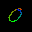

0 expected, 8 found with score 0.8341


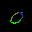

3 expected, 2 found with score 0.8504


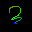

3 expected, 2 found with score 0.9056


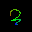

3 expected, 2 found with score 0.7863


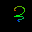

3 expected, 2 found with score 0.7698


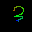

3 expected, 2 found with score 0.9142


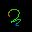

3 expected, 2 found with score 0.9141


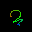

3 expected, 2 found with score 0.8757


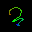

6 expected, 0 found with score 0.8658


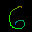

98.7% correct (N=794, 306 unknown)


In [16]:
from IPython.display import Image, display

SCORE_THRESHOLD = 0.75

correct_count = 0
wrong_count = 0
discarded_count = 0

for label_dir in sorted(Path("test").iterdir()):
    if not label_dir.is_dir():
        continue

    expected_label = label_dir.name
    for filename in sorted(label_dir.glob("*.png")):
        index, predicted_label, score = predict_image(model, filename)

        if score < SCORE_THRESHOLD:
            discarded_count += 1
            continue

        if predicted_label == expected_label:
            correct_count += 1
        else:
            wrong_count += 1
            print(f"{expected_label} expected, {predicted_label} found with score {score:.4f}")
            display(Image(filename=str(filename)))

denominator = correct_count + wrong_count
correct_percentage = (correct_count / denominator) * 100 if denominator else 0.0
print(f"{correct_percentage:.1f}% correct (N={denominator}, {discarded_count} unknown)")


In [17]:
# Keras 3 native format for reloading in Python.
model.save(KERAS_MODEL_FILENAME)

# TensorFlow SavedModel export for serving and TFLite conversion.
model.export(SAVED_MODEL_DIR)

print("Saved Keras model:", Path(KERAS_MODEL_FILENAME).resolve())
print("Exported SavedModel:", SAVED_MODEL_DIR.resolve())


INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2068461471696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461475920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461479568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461479760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461471120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461478416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461478608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461479184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461479952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461480720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2068461480528: TensorSpec(shape=(), dtyp

In [18]:
# Convert the SavedModel to a float TFLite model.
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
model_no_quant_tflite = converter.convert()

Path(FLOAT_TFL_MODEL_FILENAME).write_bytes(model_no_quant_tflite)
print("Wrote:", FLOAT_TFL_MODEL_FILENAME)


Wrote: float_model.tflite


In [19]:
def representative_dataset():
    # A modest calibration set is enough for this small model.
    # Use training images, not test images, to avoid peeking at the test set.
    for filename in sorted(Path("train").glob("*/*.png"))[:1000]:
        yield [load_image_array(filename)]

converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Enforce integer-only quantization for TensorFlow Lite Micro style deployment.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_dataset

model_tflite = converter.convert()

Path(QUANTIZED_TFL_MODEL_FILENAME).write_bytes(model_tflite)
print("Wrote:", QUANTIZED_TFL_MODEL_FILENAME)


Wrote: quantized_model.tflite


In [20]:
def predict_tflite(tflite_model, filename):
    img_array = load_image_array(filename)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    if input_scale != 0:
        img_array = (img_array / input_scale) + input_zero_point

    img_array = img_array.astype(input_details["dtype"])
    interpreter.set_tensor(input_details["index"], img_array)
    interpreter.invoke()

    pred = interpreter.get_tensor(output_details["index"])[0]

    output_scale, output_zero_point = output_details["quantization"]
    if output_scale != 0:
        pred = output_scale * (pred.astype(np.float32) - output_zero_point)

    predicted_label_index = int(np.argmax(pred))
    predicted_score = float(pred[predicted_label_index])
    predicted_label = class_names[predicted_label_index]
    return predicted_label_index, predicted_label, predicted_score


In [21]:
predict_tflite(model_no_quant_tflite, sample_file)

c:\Users\Linh B Ngo\.conda\envs\tinyml\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


(7, '7', 0.8086853623390198)

In [22]:
predict_tflite(model_tflite, sample_file)

(7, '7', 0.765625)

0 expected, 8 found with score 0.7773


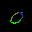

3 expected, 2 found with score 0.8789


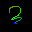

3 expected, 2 found with score 0.9180


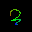

3 expected, 2 found with score 0.8125


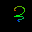

3 expected, 2 found with score 0.7891


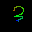

3 expected, 2 found with score 0.9219


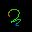

3 expected, 2 found with score 0.9258


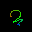

3 expected, 2 found with score 0.8945


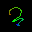

6 expected, 0 found with score 0.7656


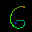

6 expected, 0 found with score 0.8750


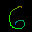

98.6% correct (N=731, 369 unknown)


In [23]:
correct_count = 0
wrong_count = 0
discarded_count = 0

for label_dir in sorted(Path("test").iterdir()):
    if not label_dir.is_dir():
        continue

    expected_label = label_dir.name
    for filename in sorted(label_dir.glob("*.png")):
        index, predicted_label, score = predict_tflite(model_tflite, filename)

        if score < SCORE_THRESHOLD:
            discarded_count += 1
            continue

        if predicted_label == expected_label:
            correct_count += 1
        else:
            wrong_count += 1
            print(f"{expected_label} expected, {predicted_label} found with score {score:.4f}")
            display(Image(filename=str(filename)))

denominator = correct_count + wrong_count
correct_percentage = (correct_count / denominator) * 100 if denominator else 0.0
print(f"{correct_percentage:.1f}% correct (N={denominator}, {discarded_count} unknown)")


In [24]:
import os
import pandas as pd

def get_dir_size(path):
    path = Path(path)
    size = 0
    for item in path.rglob("*"):
        if item.is_file():
            size += item.stat().st_size
    return size

size_tf = get_dir_size(SAVED_MODEL_DIR)
size_no_quant_tflite = Path(FLOAT_TFL_MODEL_FILENAME).stat().st_size
size_tflite = Path(QUANTIZED_TFL_MODEL_FILENAME).stat().st_size

pd.DataFrame.from_records(
    [
        ["TensorFlow SavedModel", f"{size_tf:,} bytes", ""],
        [
            "TensorFlow Lite",
            f"{size_no_quant_tflite:,} bytes",
            f"(reduced by {size_tf - size_no_quant_tflite:,} bytes)",
        ],
        [
            "TensorFlow Lite Quantized",
            f"{size_tflite:,} bytes",
            f"(reduced by {size_no_quant_tflite - size_tflite:,} bytes)",
        ],
    ],
    columns=["Model", "Size", "Change"],
    index="Model",
)


,Size,Change
Model,,
TensorFlow SavedModel,"342,672 bytes",
TensorFlow Lite,"101,936 bytes","(reduced by 240,736 bytes)"
TensorFlow Lite Quantized,"32,960 bytes","(reduced by 68,976 bytes)"


In [25]:
# Convert the quantized TFLite model into a C source array without xxd/sed.
# This is portable across Windows, macOS, and Linux.
import pathlib

def write_tflite_micro_cc(tflite_path, cc_path):
    data = pathlib.Path(tflite_path).read_bytes()

    lines = []

    for i in range(0, len(data), 12):
        chunk = data[i:i + 12]
        hex_values = ", ".join(f"0x{byte:02x}" for byte in chunk)
        lines.append(f"  {hex_values},\n")

    pathlib.Path(cc_path).write_text("".join(lines), encoding="utf-8")
    print(f"Wrote C array to {cc_path} with {len(data)} bytes of data.")

write_tflite_micro_cc(QUANTIZED_TFL_MODEL_FILENAME, TFL_CC_MODEL_FILENAME)
    
print("Wrote:", QUANTIZED_TFL_MODEL_FILENAME)
print("C array size:", pathlib.Path(TFL_CC_MODEL_FILENAME).stat().st_size, "bytes")
"""
def tflite_to_c_array(input_path, output_path, array_name="g_magic_wand_model_data", line_width=12):
    data = Path(input_path).read_bytes()

    with Path(output_path).open("w", encoding="utf-8") as f:
        f.write("// This file was generated by the training notebook.\n")
        f.write("#include <cstdint>\n\n")
        f.write(f"alignas(16) const unsigned char {array_name}[] = {{\n")

        for offset in range(0, len(data), line_width):
            chunk = data[offset:offset + line_width]
            values = ", ".join(f"0x{byte:02x}" for byte in chunk)
            f.write(f"  {values},\n")

        f.write("};\n")
        f.write(f"const int {array_name}_len = {len(data)};\n")

tflite_to_c_array(QUANTIZED_TFL_MODEL_FILENAME, TFL_CC_MODEL_FILENAME)
print("Wrote:", Path(TFL_CC_MODEL_FILENAME).resolve())
"""

Wrote C array to magic_wand_model_data.cc with 32960 bytes of data.
Wrote: quantized_model.tflite
C array size: 206001 bytes


'\ndef tflite_to_c_array(input_path, output_path, array_name="g_magic_wand_model_data", line_width=12):\n    data = Path(input_path).read_bytes()\n\n    with Path(output_path).open("w", encoding="utf-8") as f:\n        f.write("// This file was generated by the training notebook.\n")\n        f.write("#include <cstdint>\n\n")\n        f.write(f"alignas(16) const unsigned char {array_name}[] = {{\n")\n\n        for offset in range(0, len(data), line_width):\n            chunk = data[offset:offset + line_width]\n            values = ", ".join(f"0x{byte:02x}" for byte in chunk)\n            f.write(f"  {values},\n")\n\n        f.write("};\n")\n        f.write(f"const int {array_name}_len = {len(data)};\n")\n\ntflite_to_c_array(QUANTIZED_TFL_MODEL_FILENAME, TFL_CC_MODEL_FILENAME)\nprint("Wrote:", Path(TFL_CC_MODEL_FILENAME).resolve())\n'

In [26]:
# Print the end of the generated C source file.
lines = Path(TFL_CC_MODEL_FILENAME).read_text(encoding="utf-8").splitlines()
print("\n".join(lines[-10:]))


  0x04, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x20, 0x00, 0x00, 0x00,
  0x20, 0x00, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00,
  0x4c, 0x00, 0x00, 0x00, 0x2c, 0x00, 0x00, 0x00, 0x18, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0xd0, 0xff, 0xff, 0xff, 0x19, 0x00, 0x00, 0x00,
  0x02, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x19, 0xe0, 0xff, 0xff, 0xff,
  0x09, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x09,
  0xf0, 0xff, 0xff, 0xff, 0x28, 0x00, 0x00, 0x00, 0x02, 0x00, 0x00, 0x00,
  0x00, 0x00, 0x00, 0x28, 0x0c, 0x00, 0x10, 0x00, 0x0f, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x0c, 0x00, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x03,
